# Verify Box setup
Dated Jun 5, 2025


Setup:

For the black box

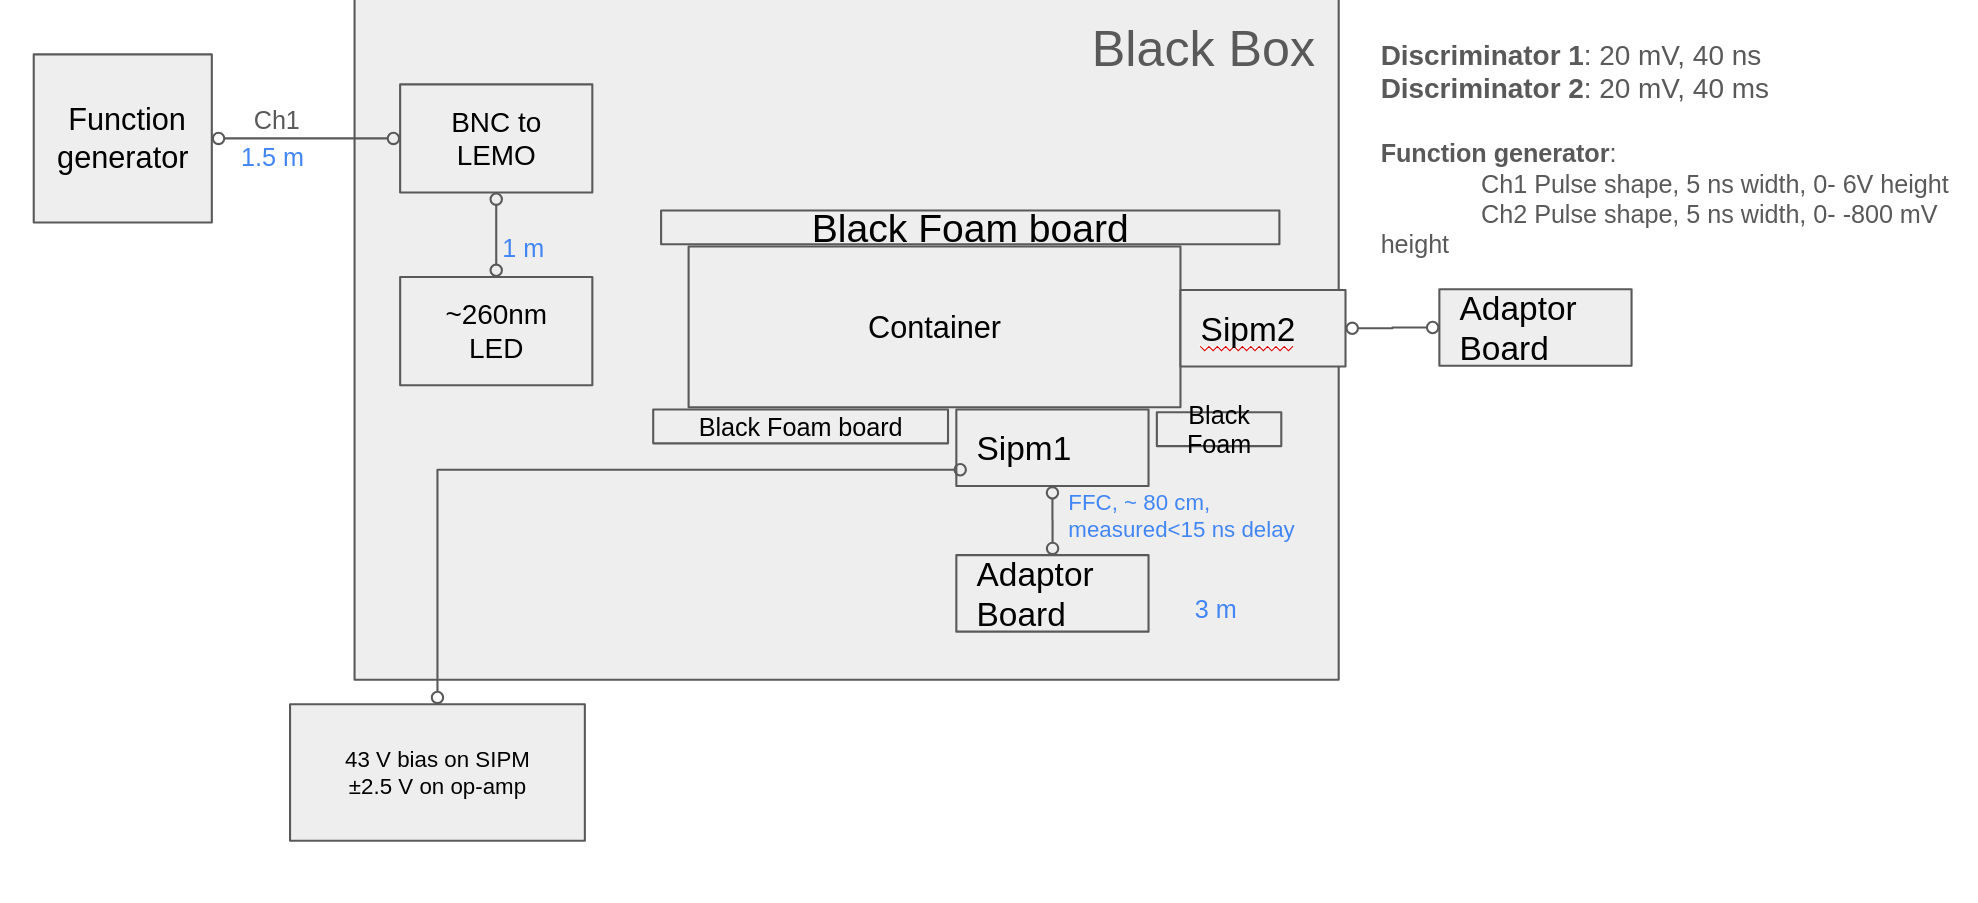

For the DAQ:

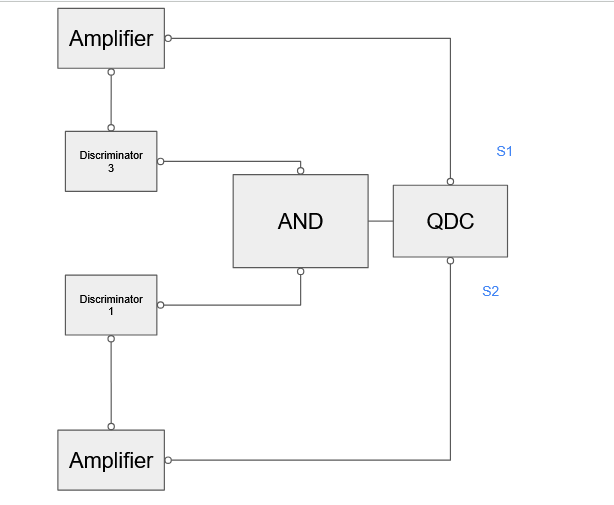


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import mplhep as hep
from scipy.signal import find_peaks
from scipy.special import factorial
from scipy.optimize import curve_fit
from scipy.stats import poisson
hep.style.use(hep.style.ROOT)

# Measurement result

In [120]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))
def calculate_poisson_mle(fwhm_sums):
    """
    Calculate the maximum likelihood estimate (MLE) for the Poisson parameter lambda
    using FWHM counts from SiPM dark count peaks.
    
    Parameters:
    fwhm_sums : list of tuples
        List of (mean, fwhm_sum) from Get_FWHM, where fwhm_sum is the count in the FWHM of each peak.
    
    Returns:
    lambda_mle : float
        MLE for the Poisson parameter lambda.
    """
    if not fwhm_sums:
        print("No peaks provided for MLE calculation.")
        return None
    
    # Extract p.e. levels (k) and counts (fwhm_sum)
    # Assume peaks are ordered as 1 p.e., 2 p.e., etc.
    k_values = np.arange(1, len(fwhm_sums) + 1)  # p.e. levels: 1, 2, 3, ...
    counts = np.array([fwhm_sum for _, fwhm_sum in fwhm_sums])
    
    # Compute MLE: lambda = sum(k * count_k) / sum(count_k)
    if np.sum(counts) == 0:
        print("No counts in FWHM sums, cannot compute MLE.")
        return None
    
    lambda_mle = np.sum(k_values * counts) / np.sum(counts)
    print(f"Poisson MLE: lambda = {lambda_mle:.4f}")
    
    return lambda_mle
def Get_FWHM(data, dist=20):
    # Create histogram
    counts, qdc_values = np.histogram(data, bins="auto")
    
    # Find peaks
    peaks, _ = find_peaks(counts, height=50, distance=dist)  # Adjust parameters as needed
    peak_centers = (qdc_values[peaks] + qdc_values[peaks + 1]) / 2  # Use bin centers
    
    fwhm_sums = []
    fit_params = []  # Store (amplitude, mean, sigma) for each peak
    for peak in peak_centers:
        # Select a range around the peak for fitting
        bin_centers = (qdc_values[:-1] + qdc_values[1:]) / 2
        mask = (bin_centers > peak - dist) & (bin_centers < peak + dist)
        x_data = bin_centers[mask]
        y_data = counts[mask]
        
        # Fit Gaussian
        try:
            popt, _ = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), peak, 10])
            amplitude, mean, sigma = popt
            fwhm = 2.355 * sigma
            
            # Sum data within FWHM
            fwhm_range = (x_data >= mean - fwhm/2) & (x_data <= mean + fwhm/2)
            fwhm_sum = np.sum(y_data[fwhm_range])
            fwhm_sums.append((mean, fwhm_sum))
            fit_params.append((amplitude, mean, sigma))
            print(f"Peak at QDC {mean:.2f}: Sum within FWHM = {fwhm_sum:.2f}")
        except:
            print(f"Fit failed for peak at QDC {peak}")
            fit_params.append(None)  # Append None for failed fits
    
    return fwhm_sums, (qdc_values[:-1], counts), (peak_centers, counts[peaks]), fit_params
def plot_peaks(qdc_edges, counts, peak_centers, peak_counts, fit_params,legendname):

    plt.figure(figsize=(10, 6))
    
    # Plot histogram using step
    plt.step(qdc_edges, counts, where="post", color="black", label="%s Dark Counts"%(legendname))
    
    # Plot vertical lines and Gaussian fits for each peak
    colors = plt.cm.viridis(np.linspace(0, 1, len(peak_centers)))  # Distinct colors
    for i, (peak, count, params, color) in enumerate(zip(peak_centers, peak_counts, fit_params, colors)):
        # Plot vertical line for peak
        plt.axvline(x=peak, color=color, linestyle="--", label=f"{i+1} p.e. (count: {int(count)})")
        
        # Plot Gaussian fit if fit was successful
        if params is not None:
            amplitude, mean, sigma = params
            # Create fine grid for Gaussian (e.g., ±3σ around mean)
            x_fit = np.linspace(mean - 3*sigma, mean + 3*sigma, 100)
            y_fit = gaussian(x_fit, amplitude, mean, sigma)
            plt.plot(x_fit, y_fit, color=color, linestyle="-", alpha=0.7, label=f"Fit {i+1} p.e.")
    plt.xlim(qdc_edges[0], qdc_edges[-1])
    # Customize plot
    plt.xlabel("QDC Value")
    plt.ylabel("Counts")
    plt.title("SiPM Dark Count Histogram with Peaks and Gaussian Fits")
    plt.legend(loc="upper right",fontsize=8)
    plt.grid(True, alpha=0.3)
    #plt.tight_layout()
    
    # Show plot
    plt.show()
def plot_poisson_pmf(fwhm_sums, lambda_mle):
    """
    Plot the observed counts from FWHM sums and the Poisson PMF for the given lambda_mle.
    
    Parameters:
    fwhm_sums : list of tuples
        List of (mean, fwhm_sum) from Get_FWHM, where fwhm_sum is the count in the FWHM of each peak.
    lambda_mle : float
        MLE for the Poisson parameter lambda from calculate_poisson_mle.
    
    Returns:
    None (displays the plot).
    """
    if not fwhm_sums or lambda_mle is None:
        print("No valid data or lambda_mle provided for Poisson PMF plot.")
        return
    
    # Extract p.e. levels (k) and observed counts
    k_values = np.arange(1, len(fwhm_sums) + 1)  # p.e. levels: 1, 2, 3, ...
    observed_counts = np.array([fwhm_sum for _, fwhm_sum in fwhm_sums])
    
    # Compute Poisson PMF for k = 0 to max(k_values) + 2 for extended range
    k_max = max(k_values) + 2
    k_pmf = np.arange(0, k_max + 1)
    pmf = poisson.pmf(k_pmf, lambda_mle)
    
    # Normalize PMF to match total observed counts
    total_counts = np.sum(observed_counts)
    pmf_normalized = pmf * total_counts / np.sum(pmf)
    
    t = np.arange(0, 20, 0.1)
    d = np.exp(-lambda_mle)*np.power(lambda_mle, t)/factorial(t)
    # Create plot
    plt.figure(figsize=(8, 6))
    plt.plot(t, d, label="Poisson", color="red")

    # Plot observed counts as bars
    plt.bar(k_values, observed_counts/total_counts, width=0.4, color="blue", alpha=0.5, label="Observed Counts")
    plt.plot("", marker="o", linestyle="--", color="green", label="Poisson PMF (λ = {:.2f})".format(lambda_mle))
    
    # Customize plot
    plt.xlabel("Number of Photoelectrons (p.e.)")
    plt.ylabel("Counts")
    plt.title("SiPM Dark Counts vs. Poisson PMF")
    plt.xticks(k_pmf)  # Show integer ticks for p.e. levels
    plt.xlim(0, k_max)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    
    # Show plot
    plt.show()

# SiPM1

Peak at QDC 513.15: Sum within FWHM = 27886.00
Peak at QDC 644.70: Sum within FWHM = 28859.00
Peak at QDC 805.94: Sum within FWHM = 10729.00
Peak at QDC 957.52: Sum within FWHM = 4649.00
Peak at QDC 1122.48: Sum within FWHM = 2460.00
Peak at QDC 1285.52: Sum within FWHM = 1222.00
Peak at QDC 1460.03: Sum within FWHM = 671.00


/tmp/ipykernel_48869/3643944008.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), peak, 10])


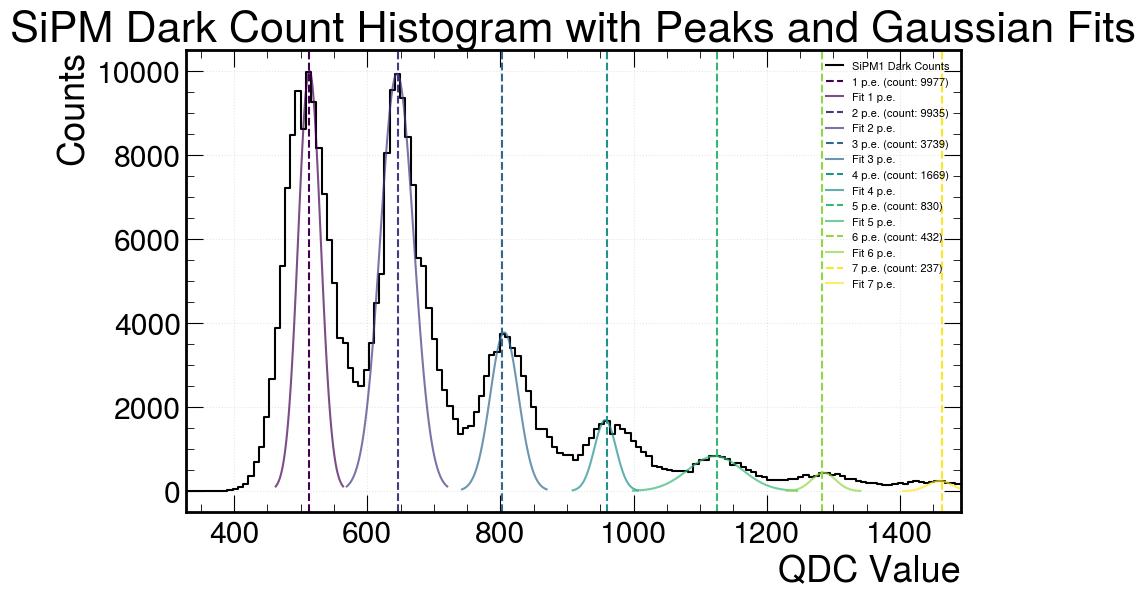

In [121]:
setup1=pd.read_csv("DarkBox/1306_blackbox_sipm1_LedOff.txt",sep=" ")
setup2=pd.read_csv("DarkBox/1306_blackbox_sipm2_LedOff.txt",sep=" ")
SiPM1=setup1["ch0"]
SiPM1=SiPM1[SiPM1<1500]
# Run Get_FWHM
fwhm_sums, (qdc_edges, counts), (peak_centers, peak_counts), fit_params = Get_FWHM(SiPM1, dist=15)
plot_peaks(qdc_edges, counts, peak_centers, peak_counts, fit_params,"SiPM1")

Poisson MLE: lambda = 2.1015
The Maximum likelihood of Poisson from this dataset=2.10152204613212


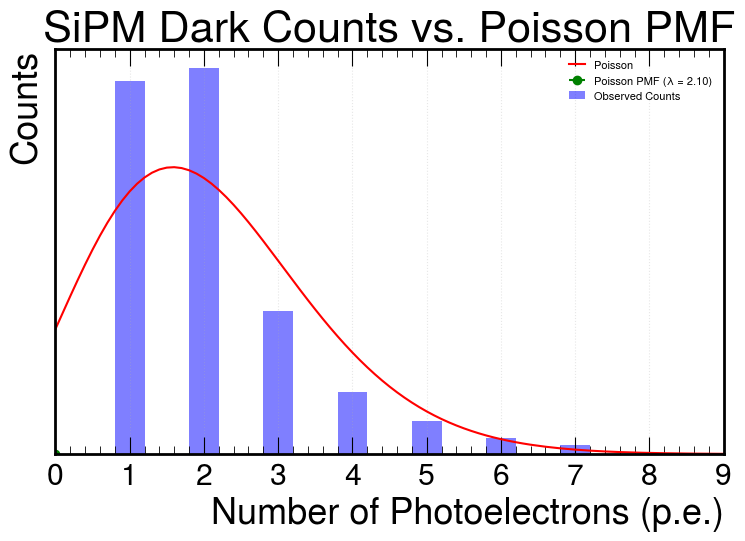

In [122]:
lambda_mle=calculate_poisson_mle(fwhm_sums)
print("The Maximum likelihood of Poisson from this dataset=%s"%(lambda_mle))
plot_poisson_pmf(fwhm_sums, lambda_mle)

# SiPM2

Peak at QDC 533.87: Sum within FWHM = 98437.00
Peak at QDC 683.14: Sum within FWHM = 48138.00
Peak at QDC 835.64: Sum within FWHM = 18126.00
Peak at QDC 990.23: Sum within FWHM = 7650.00
Peak at QDC 1144.43: Sum within FWHM = 3802.00
Peak at QDC 1300.61: Sum within FWHM = 1858.00
Peak at QDC 1450.40: Sum within FWHM = 982.00
Poisson MLE: lambda = 1.7695
The Maximum likelihood of Poisson from this dataset=1.7694714318437035


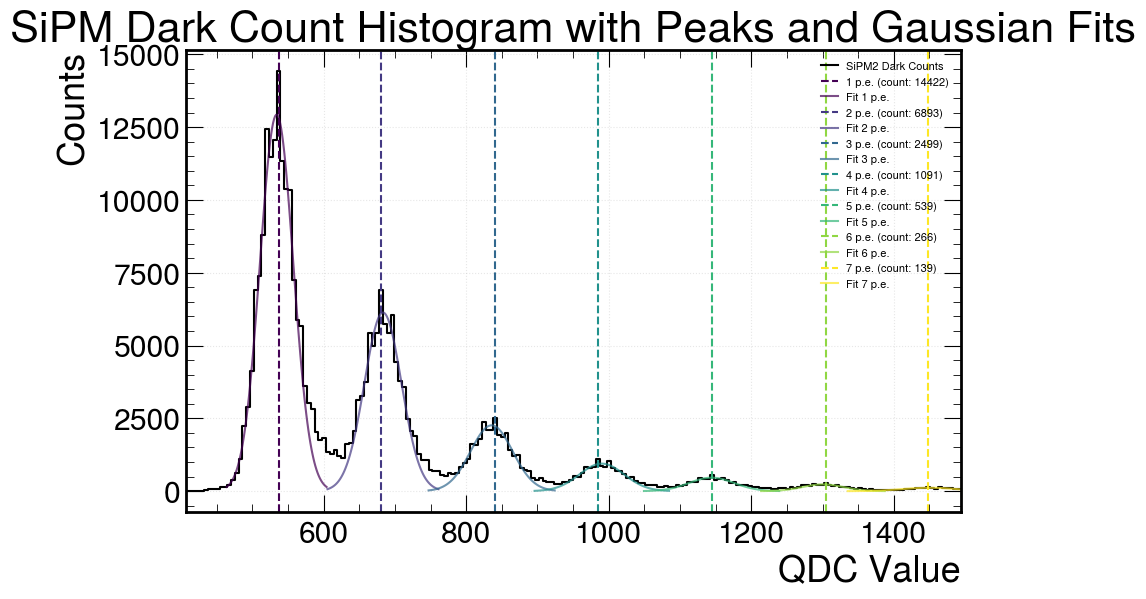

In [123]:
setup1=pd.read_csv("DarkBox/1306_blackbox_sipm1_LedOff.txt",sep=" ")
setup2=pd.read_csv("DarkBox/1306_blackbox_sipm2_LedOff.txt",sep=" ")
SiPM2=setup2["ch1"]
SiPM2=SiPM2[SiPM2<1500]
# Run Get_FWHM
fwhm_sums, (qdc_edges, counts), (peak_centers, peak_counts), fit_params = Get_FWHM(SiPM2, dist=25)
print("The Maximum likelihood of Poisson from this dataset=%s"%(calculate_poisson_mle(fwhm_sums)))
plot_peaks(qdc_edges, counts, peak_centers, peak_counts, fit_params,"SiPM2")

Poisson MLE: lambda = 1.7695
The Maximum likelihood of Poisson from this dataset=1.7694714318437035


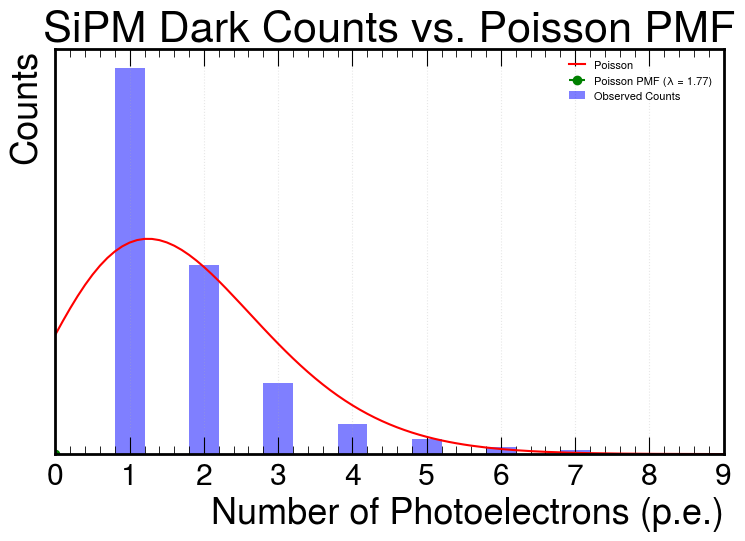

In [124]:
lambda_mle=calculate_poisson_mle(fwhm_sums)
print("The Maximum likelihood of Poisson from this dataset=%s"%(lambda_mle))
plot_poisson_pmf(fwhm_sums, lambda_mle)

# Coincidence SiPM1

Peak at QDC 524.80: Sum within FWHM = 85591.00
Peak at QDC 683.07: Sum within FWHM = 34720.00
Peak at QDC 847.27: Sum within FWHM = 13329.00
Peak at QDC 1018.03: Sum within FWHM = 5642.00
Peak at QDC 1170.93: Sum within FWHM = 2845.00
Peak at QDC 1321.55: Sum within FWHM = 1376.00
Peak at QDC 1494.31: Sum within FWHM = 626.00
Poisson MLE: lambda = 1.6960
The Maximum likelihood of Poisson from this dataset=1.6960431280311388


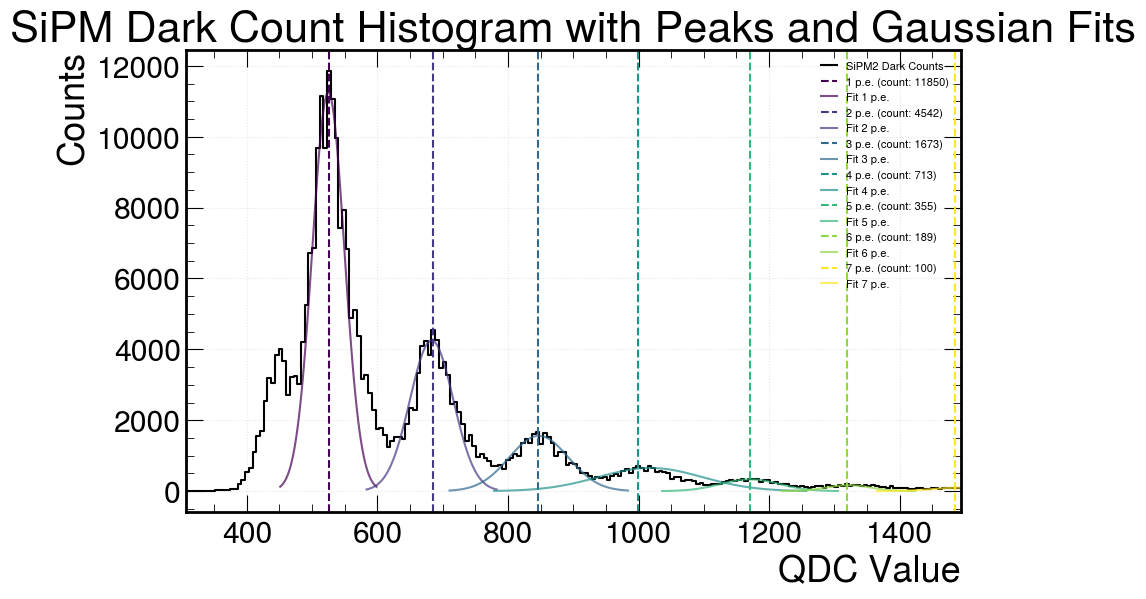

In [125]:
setup1=pd.read_csv("DarkBox/1306_blackbox_sipm12_LedOff.txt",sep=" ")
SiPM1=setup1["ch0"]
SiPM2=setup1["ch1"]
SiPM1=SiPM1[SiPM1<1500]
SiPM2=SiPM2[SiPM2<1500]
# Run Get_FWHM
fwhm_sums, (qdc_edges, counts), (peak_centers, peak_counts), fit_params = Get_FWHM(SiPM1, dist=25)
print("The Maximum likelihood of Poisson from this dataset=%s"%(calculate_poisson_mle(fwhm_sums)))
plot_peaks(qdc_edges, counts, peak_centers, peak_counts, fit_params,"SiPM2")

Poisson MLE: lambda = 1.6960
The Maximum likelihood of Poisson from this dataset=1.6960431280311388


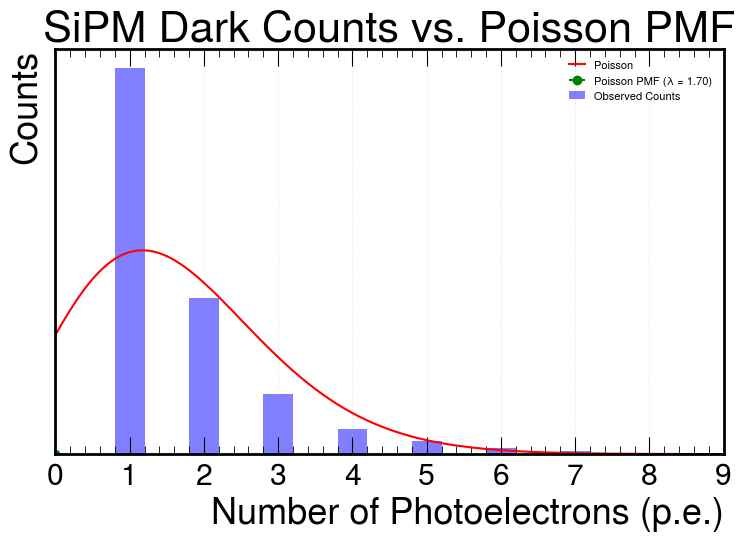

In [126]:
lambda_mle=calculate_poisson_mle(fwhm_sums)
print("The Maximum likelihood of Poisson from this dataset=%s"%(lambda_mle))
plot_poisson_pmf(fwhm_sums, lambda_mle)

# Coincidence SiPM2

Peak at QDC 571.31: Sum within FWHM = 109491.00
Peak at QDC 726.30: Sum within FWHM = 32669.00
Peak at QDC 883.27: Sum within FWHM = 11840.00
Peak at QDC 1036.06: Sum within FWHM = 5056.00
Peak at QDC 1190.63: Sum within FWHM = 2422.00
Peak at QDC 1348.29: Sum within FWHM = 1087.00
Peak at QDC 1545.86: Sum within FWHM = 388.00
Poisson MLE: lambda = 1.5460
The Maximum likelihood of Poisson from this dataset=1.5459733788270238


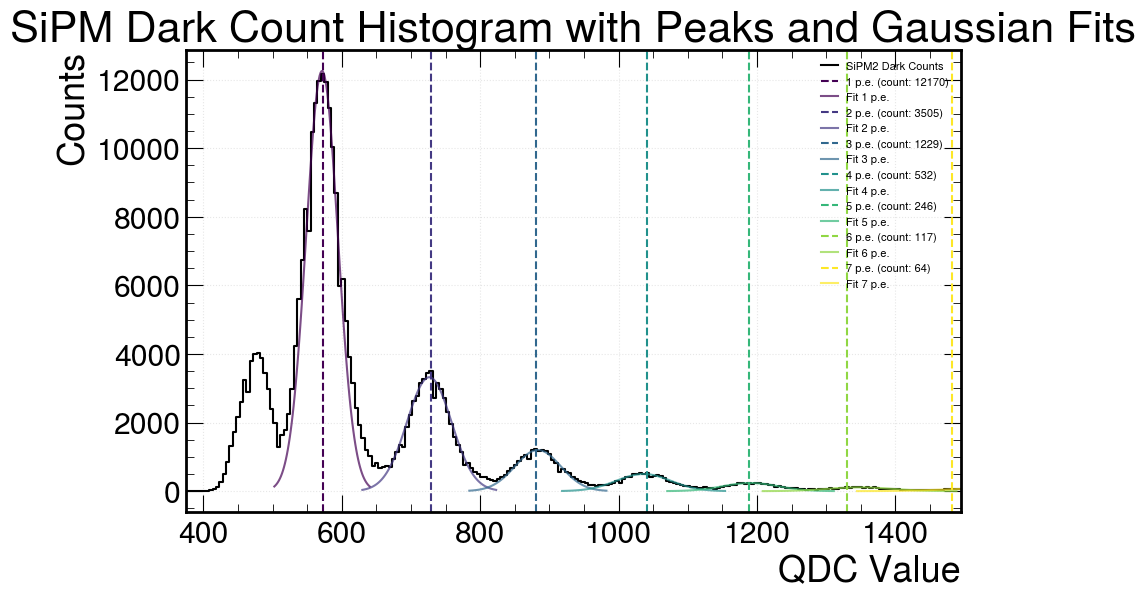

In [127]:
setup1=pd.read_csv("DarkBox/1306_blackbox_sipm12_LedOff.txt",sep=" ")
SiPM1=setup1["ch0"]
SiPM2=setup1["ch1"]
SiPM1=SiPM1[SiPM1<1500]
SiPM2=SiPM2[SiPM2<1500]
# Run Get_FWHM
fwhm_sums, (qdc_edges, counts), (peak_centers, peak_counts), fit_params = Get_FWHM(SiPM2, dist=25)
print("The Maximum likelihood of Poisson from this dataset=%s"%(calculate_poisson_mle(fwhm_sums)))
plot_peaks(qdc_edges, counts, peak_centers, peak_counts, fit_params,"SiPM2")

Poisson MLE: lambda = 1.5460
The Maximum likelihood of Poisson from this dataset=1.5459733788270238


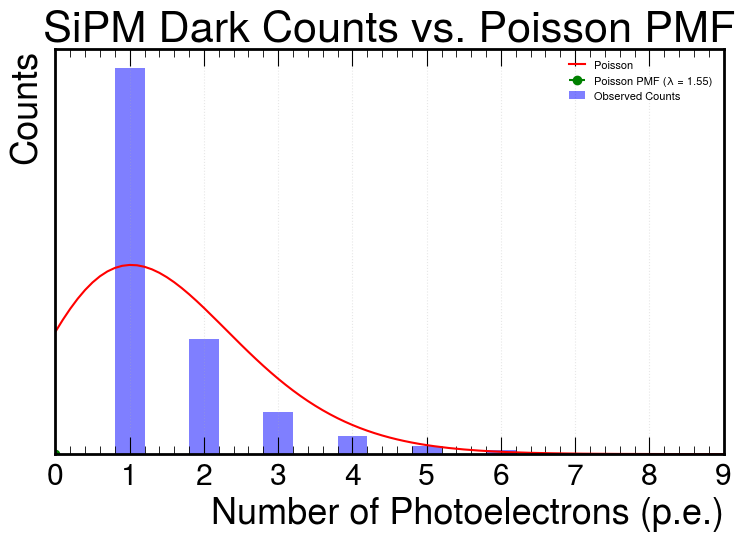

In [128]:
lambda_mle=calculate_poisson_mle(fwhm_sums)
print("The Maximum likelihood of Poisson from this dataset=%s"%(lambda_mle))
plot_poisson_pmf(fwhm_sums, lambda_mle)